In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
import sklearn
from sklearn.model_selection import train_test_split
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryCrossentropy
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold

2026-03-29 08:53:03.169416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774774383.416540      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774774383.485584      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774774384.013366      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774774384.013411      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774774384.013414      24 computation_placer.cc:177] computation placer alr

In [2]:
base_path = '/kaggle/input/datasets/abhijithc/covid-pneumonia-lus-images/covid_pneumonia'

In [3]:
for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))}")

pneumonia: 463
covid: 524


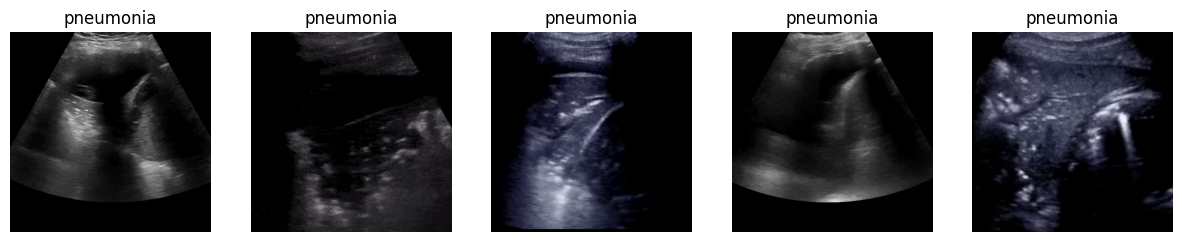

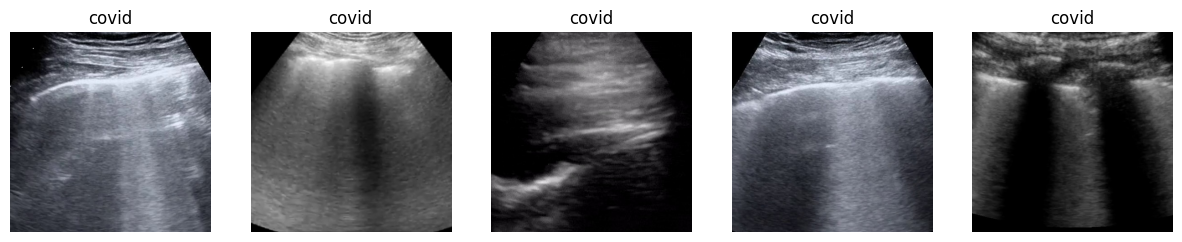

In [4]:
def show_samples(class_path, class_name, n=5):
    images = os.listdir(class_path)
    samples = random.sample(images, min(n, len(images)))

    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(samples):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.show()

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        show_samples(cls_path, cls)

In [5]:
def get_video_id(path):
    filename = os.path.basename(path)
    filename = filename.split('.')[0]
    filename = filename.replace('-', '_')
    parts = filename.split('_')
    return '_'.join(parts[:2])

In [6]:
image_paths = []
labels = []

for label in os.listdir(base_path):
    class_path = os.path.join(base_path, label)
    for img in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, img))
        labels.append(label)

df = pd.DataFrame({
    "filename": image_paths,
    "label": labels
})

df["video_id"] = df["filename"].apply(get_video_id)
df.tail()

,filename,label,video_id
982,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_Atlas
983,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_denault
984,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_recommendations
985,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_convex
986,/kaggle/input/datasets/abhijithc/covid-pneumon...,covid,Cov_convex


In [7]:
video_df = df.groupby("video_id").first().reset_index()

print(video_df['label'].value_counts())

label
covid        11
pneumonia    10
Name: count, dtype: int64


In [8]:
video_sizes = df.groupby("video_id").size()

video_info = video_df.copy()
video_info["num_frames"] = video_info["video_id"].map(video_sizes)

print(video_info.sort_values("num_frames", ascending=False).head(10))

               video_id                                           filename  \
19     Pneu_northumbria  /kaggle/input/datasets/abhijithc/covid-pneumon...   
5            Cov_convex  /kaggle/input/datasets/abhijithc/covid-pneumon...   
0             Cov_Atlas  /kaggle/input/datasets/abhijithc/covid-pneumon...   
4        Cov_combatting  /kaggle/input/datasets/abhijithc/covid-pneumon...   
6           Cov_denault  /kaggle/input/datasets/abhijithc/covid-pneumon...   
12             Pneu_Avi  /kaggle/input/datasets/abhijithc/covid-pneumon...   
8   Cov_recommendations  /kaggle/input/datasets/abhijithc/covid-pneumon...   
11           Pneu_Atlas  /kaggle/input/datasets/abhijithc/covid-pneumon...   
7            Cov_emdocs  /kaggle/input/datasets/abhijithc/covid-pneumon...   
20      pneu_radiopaeda  /kaggle/input/datasets/abhijithc/covid-pneumon...   

        label  num_frames  
19  pneumonia         272  
5       covid         150  
0       covid          93  
4       covid          88  
6

In [9]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, tmp_idx = next(
    sgkf.split(df, y=df["label"], groups=df["video_id"])
)

train_df = df.iloc[train_idx]
tmp_df   = df.iloc[tmp_idx]

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)

val_idx, test_idx = next(
    sgkf2.split(tmp_df, y=tmp_df["label"], groups=tmp_df["video_id"])
)

val_df  = tmp_df.iloc[val_idx]
test_df = tmp_df.iloc[test_idx]

In [10]:
print("Train:\n", train_df['label'].value_counts(normalize=True))
print("Val:\n", val_df['label'].value_counts(normalize=True))
print("Test:\n", test_df['label'].value_counts(normalize=True))

Train:
 label
covid        0.695024
pneumonia    0.304976
Name: proportion, dtype: float64
Val:
 label
pneumonia    0.989091
covid        0.010909
Name: proportion, dtype: float64
Test:
 label
covid        0.988764
pneumonia    0.011236
Name: proportion, dtype: float64


In [11]:
train_df = pd.DataFrame({
    "x": train_df["filename"],
    "y": train_df["label"]
}) 

val_df = pd.DataFrame({
    "x": val_df["filename"],
    "y": val_df["label"]
})

test_df = pd.DataFrame({
    "x": test_df["filename"],
    "y": test_df["label"]
})

In [12]:
train_batches = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    dataframe = train_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_batches = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    dataframe = val_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

test_batches = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    dataframe = test_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

Found 623 validated image filenames belonging to 2 classes.
Found 275 validated image filenames belonging to 2 classes.
Found 89 validated image filenames belonging to 2 classes.


In [13]:
images, labels = next(train_batches)

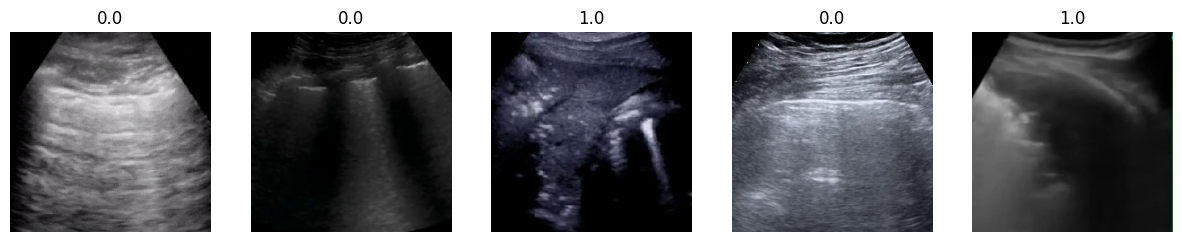

In [14]:
plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.show()

In [15]:
model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2,2), strides=2),
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2,2), strides=2),
    Flatten(),
    Dense(units=1, activation="sigmoid")
])

I0000 00:00:1774774413.297605      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774774413.304038      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       200,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,097 (859.75 KB)

 Trainable params: 220,097 (859.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

In [18]:
model.fit(x=train_batches, validation_data=val_batches, epochs=10, verbose=2)

Epoch 1/10


I0000 00:00:1774774416.874627      76 service.cc:152] XLA service 0x7c2050107170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774774416.874686      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774774416.874694      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774774417.265784      76 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774774420.796271      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 - 17s - 830ms/step - accuracy: 0.6918 - loss: 0.4965 - val_accuracy: 0.2436 - val_loss: 0.8294
Epoch 2/10
20/20 - 3s - 144ms/step - accuracy: 0.9053 - loss: 0.3155 - val_accuracy: 0.5564 - val_loss: 0.6043
Epoch 3/10
20/20 - 3s - 148ms/step - accuracy: 0.9278 - loss: 0.2023 - val_accuracy: 0.7891 - val_loss: 0.3872
Epoch 4/10
20/20 - 3s - 166ms/step - accuracy: 0.9695 - loss: 0.1407 - val_accuracy: 0.6036 - val_loss: 0.5749
Epoch 5/10
20/20 - 3s - 156ms/step - accuracy: 0.9888 - loss: 0.0924 - val_accuracy: 0.6473 - val_loss: 0.5771
Epoch 6/10
20/20 - 3s - 148ms/step - accuracy: 0.9920 - loss: 0.0703 - val_accuracy: 0.7636 - val_loss: 0.4383
Epoch 7/10
20/20 - 3s - 145ms/step - accuracy: 0.9920 - loss: 0.0516 - val_accuracy: 0.8109 - val_loss: 0.3938
Epoch 8/10
20/20 - 3s - 144ms/step - accuracy: 0.9904 - loss: 0.0411 - val_accuracy: 0.6982 - val_loss: 0.5522
Epoch 9/10
20/20 - 3s - 143ms/step - accuracy: 0.9936 - loss: 0.0309 - val_accuracy: 0.7309 - val_loss: 0.4410
Epoch 10/10

In [19]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test_batches)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(test_batches.classes, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 535ms/step
[[88  0]
 [ 0  1]]


In [20]:
test_loss, test_acc = model.evaluate(test_batches)
print(test_acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - accuracy: 1.0000 - loss: 0.0342
1.0
